In [1]:
pin_file = r"C:\repositories\mokapot\data\phospho_rep1.pin"
fasta_file = r"C:\repositories\mokapot\data\human_sp_td.fasta"

In [2]:
import os                       # For file paths
import numpy as np              # For math
import pandas as pd             # To load and work with the results
import matplotlib.pyplot as plt # To plot the results

import mokapot

In [3]:
out_dir = "percolator_comparison_output"
os.makedirs(out_dir, exist_ok=True)

In [4]:
!percolator {pin_file} \
    --results-psms {out_dir}/percolator.psms.txt \
    --results-peptides {out_dir}/percolator.peptides.txt \
    --results-proteins {out_dir}/percolator.proteins.txt \
    --picked-protein {fasta_file} \
    --protein-decoy-pattern decoy_ \
    --post-processing-tdc # Use target decoy competition instead of mix-max.

Percolator version 3.06.0, Build Date Mar  7 2025 18:31:24
Copyright (c) 2006-9 University of Washington. All rights reserved.
Written by Lukas Käll (lukall@u.washington.edu) in the
Department of Genome Sciences at the University of Washington.
Issued command:
percolator C:\repositories\mokapot\data\phospho_rep1.pin --results-psms percolator_comparison_output/percolator.psms.txt --results-peptides percolator_comparison_output/percolator.peptides.txt --results-proteins percolator_comparison_output/percolator.proteins.txt --picked-protein C:\repositories\mokapot\data\human_sp_td.fasta --protein-decoy-pattern decoy_ --post-processing-tdc # Use target decoy competition instead of mix-max.
Started Fri Oct 17 15:07:01 2025
Hyperparameters: selectionFdr=0.01, Cpos=0, Cneg=0, maxNiter=10


In [5]:
!mokapot {pin_file} --dest_dir {out_dir} --proteins {fasta_file}

[INFO] mokapot version 0.10.0
[INFO] Written by William E. Fondrie (wfondrie@uw.edu) in the
[INFO] Department of Genome Sciences at the University of Washington.
[INFO] Command issued:
[INFO] C:\Users\jiawe\.conda\envs\bio\Scripts\mokapot C:\repositories\mokapot\data\phospho_rep1.pin --dest_dir percolator_comparison_output --proteins C:\repositories\mokapot\data\human_sp_td.fasta
[INFO] 
[INFO] Starting Analysis
[INFO] =================
[INFO] Parsing PSMs...
[INFO] Reading C:\repositories\mokapot\data\phospho_rep1.pin...
C:\Users\jiawe\.conda\envs\bio\Lib\site-packages\mokapot\parsers\pin.py:238: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  yield psms.apply(pd.to_numeric, errors="ignore")
[INFO] Using 21 features:
[INFO]   (1)	lnrSp
[INFO]   (2)	deltLCn
[INFO]   (3)	deltCn
[INFO]   (4)	Sp
[INFO]   (5)	IonFrac
[INFO]   (6)	RefactoredXCorr
[INFO]   (7)	NegLog10PValue
[IN

In [7]:
# Read the result files:
perc_psms = mokapot.read_percolator(os.path.join(out_dir, "percolator.psms.txt"))
moka_psms = pd.read_table(os.path.join(out_dir, "mokapot.psms.txt"))

# Change column names so we can merge tables:
perc_psms = perc_psms.rename(
    columns={"PSMId": "SpecId",
             "peptide": "Peptide",
             "proteinIds": "Proteins",
             "score": "percolator score",
             "q-value": "percolator q-value",
             "posterior_error_prob": "percolator PEP"})

# Merge the result files.
psms = pd.merge(moka_psms, perc_psms)
psms.head()

C:\Users\jiawe\.conda\envs\bio\Lib\site-packages\mokapot\parsers\pin.py:238: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  yield psms.apply(pd.to_numeric, errors="ignore")


,SpecId,Label,ScanNr,ExpMass,CalcMass,Peptide,mokapot score,mokapot q-value,mokapot PEP,Proteins,percolator score,percolator q-value,percolator PEP
0,target_0_48845_5_-1,True,48845,5269.5756,5269.5728,R.RGNVAGDSKNDPPMEAAGFTAQVIILNHPGQISAGYAPVLDCHT...,11.170685,0.000052,6.305117e-16,sp|P68104|EF1A1_HUMAN,10.7793,0.000051,6.305120e-16
1,target_0_51371_4_-1,True,51371,4051.1223,4051.1086,K.KLHEEEIQELQAQIQEQHVQIDVDVSKPDLTAALR.D,11.129546,0.000052,6.305117e-16,sp|P08670|VIME_HUMAN,10.7575,0.000051,6.305120e-16
2,target_0_41715_3_-1,True,41715,4473.8359,4473.8286,K.ALGKYGPADVEDTTGSGATDSKDDDDIDLFGS[79.97]DDEEE...,10.228515,0.000052,6.305117e-16,sp|P24534|EF1B_HUMAN,10.3254,0.000051,6.305120e-16
3,target_0_40746_5_-1,True,40746,5586.4609,5586.4536,K.KLVHNALANLDGHPEDKPTHIIFGS[79.97]DS[79.97]ECE...,10.190804,0.000052,6.305117e-16,sp|Q76FK4|NOL8_HUMAN,10.3361,0.000051,6.305120e-16
4,target_0_31886_3_-1,True,31886,3450.7612,3450.7544,R.AAAAVAAAASSCRPLGSGAGPGPTGAAPVSAPAPGPGPAGK.G,10.156036,0.000052,6.305117e-16,sp|Q9NRL3|STRN4_HUMAN,10.1376,0.000051,6.305120e-16


In [8]:
perc_passing = (psms["percolator q-value"] <= 0.01).sum()
moka_passing = (psms["mokapot q-value"] <= 0.01).sum()
print(f"Percolator found {perc_passing} PSMs at 1% FDR.")
print(f"mokapot found {moka_passing} PSMs at 1% FDR.")

Percolator found 27617 PSMs at 1% FDR.
mokapot found 27654 PSMs at 1% FDR.


In [9]:
def comparison_plot(x, y, ax=None):
    """
    Create a scatter plot with equal axis scales.

    Plot x against y, where the axis limits are scaled
    to be equal. Additionally a y=x line is added.

    Parameters
    ----------
    x, y : numpy.ndarray
        The points to plot
    ax : matplotlib.axes.Axes
        The matplotlib axes to plot on.

    Returns
    -------
    matplotlib.axes.Axes
        The axes with the plot.
    """
    if ax is None:
        ax = plt.gca()

    corr = np.corrcoef(x, y)[0, 1]
    ax.text(0.05, 0.95, f"Pearson's r = {corr:0.4f}",
            transform=ax.transAxes, va="top")
    ax.scatter(x, y, s=10, alpha=0.1, edgecolor="none", c="#24B8A0")
    lims = [np.min([ax.get_xlim(), ax.get_ylim()]),
            np.max([ax.get_xlim(), ax.get_ylim()])]
    ax.plot(lims, lims, c="black", zorder=0, linewidth=1)
    ax.set_aspect('equal')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    return ax

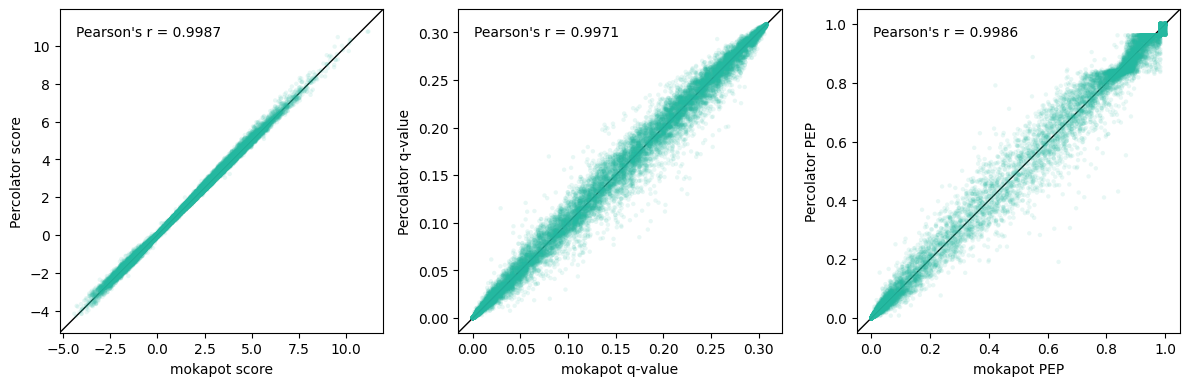

In [10]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
comparison_plot(psms["mokapot score"], psms["percolator score"], axs[0])
comparison_plot(psms["mokapot q-value"], psms["percolator q-value"], axs[1])
comparison_plot(psms["mokapot PEP"], psms["percolator PEP"], axs[2])

for ax, lab in zip(axs, ["score", "q-value", "PEP"]):
    ax.set_xlabel(f"mokapot {lab}")
    ax.set_ylabel(f"Percolator {lab}")

plt.tight_layout()
plt.show()

C:\Users\jiawe\.conda\envs\bio\Lib\site-packages\mokapot\parsers\pin.py:238: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  yield psms.apply(pd.to_numeric, errors="ignore")


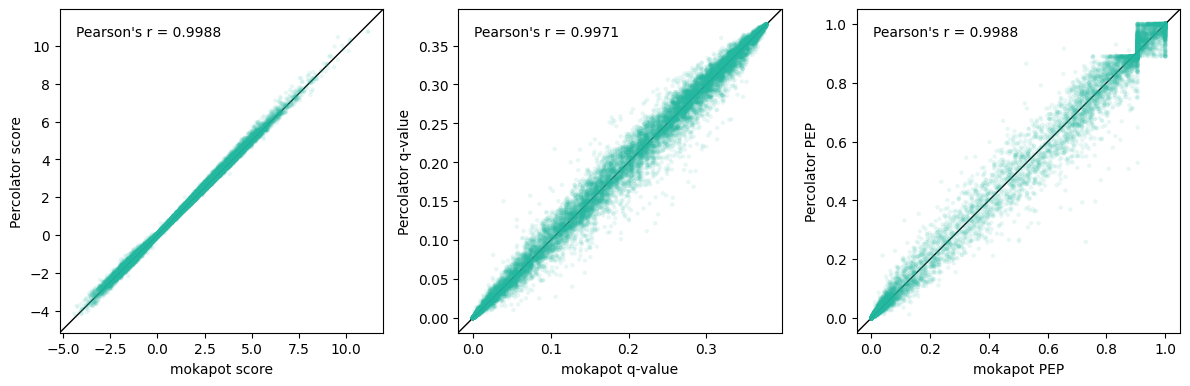

In [11]:
# Read the result files:
perc_peps = mokapot.read_percolator(os.path.join(out_dir, "percolator.peptides.txt"))
moka_peps = pd.read_table(os.path.join(out_dir, "mokapot.peptides.txt"))

# Change column names so we can merge tables:
perc_peps = perc_peps.rename(
    columns={"PSMId": "SpecId",
             "peptide": "Peptide",
             "proteinIds": "Proteins",
             "score": "percolator score",
             "q-value": "percolator q-value",
             "posterior_error_prob": "percolator PEP"})

# Merge the result files:
peps = pd.merge(moka_peps, perc_peps)

# Plot the results:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
comparison_plot(peps["mokapot score"], peps["percolator score"], axs[0])
comparison_plot(peps["mokapot q-value"], peps["percolator q-value"], axs[1])
comparison_plot(peps["mokapot PEP"], peps["percolator PEP"], axs[2])

for ax, lab in zip(axs, ["score", "q-value", "PEP"]):
    ax.set_xlabel(f"mokapot {lab}")
    ax.set_ylabel(f"Percolator {lab}")

plt.tight_layout()
plt.show()

C:\Users\jiawe\.conda\envs\bio\Lib\site-packages\mokapot\parsers\pin.py:238: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  yield psms.apply(pd.to_numeric, errors="ignore")


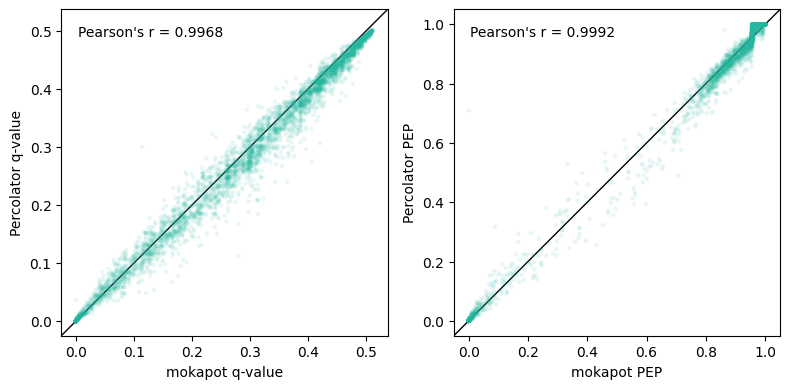

In [12]:
# Read the result files:
perc_prots = mokapot.read_percolator(os.path.join(out_dir, "percolator.proteins.txt"))
moka_prots = pd.read_table(os.path.join(out_dir, "mokapot.proteins.txt"))

# Use just the first protein from mokapot results:
moka_prots["ProteinId"] = moka_prots["mokapot protein group"].str.split(", ", expand=True)[0]

# Merge mokapot and Percolator results
prots = pd.merge(moka_prots, perc_prots)

# Plot the results:
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
comparison_plot(prots["mokapot q-value"], prots["q-value"], axs[0])
comparison_plot(prots["mokapot PEP"], prots["posterior_error_prob"], axs[1])

for ax, lab in zip(axs, ["q-value", "PEP"]):
    ax.set_xlabel(f"mokapot {lab}")
    ax.set_ylabel(f"Percolator {lab}")

plt.tight_layout()
plt.show()